# Лабораторная работа №1
## Графовый анализ публикаций по теме Retrieval-Augmented Generation

В работе анализируется корпус публикаций arXiv по запросу `all:"retrieval augmented generation"`. Цель работы: выделить ключевые слова, построить графы ключевых слов и публикаций, найти тематические сообщества и реализовать поиск похожих публикаций.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path('.')
df = pd.read_csv(ROOT / 'data/rag_arxiv_2020plus.csv')
summary = json.loads((ROOT / 'data/analysis_summary.json').read_text(encoding='utf-8'))
print(f'Число публикаций: {len(df)}')
print(f"Период публикаций: {df['published'].min()} — {df['published'].max()}")
df[['id', 'published', 'title', 'authors']].head()

Число публикаций: 400
Период публикаций: 2026-08-07 — 2026-10-02


,id,published,title,authors
0,2610.03632v1,2026-10-02,World Embedding Benchmark,Yiqi Liu; Ruifeng Yuan; Yang Wang; Long Li; Fe...
1,2610.03421v1,2026-10-02,CLIMB: Confidence-Guided Complementary Evidenc...,Hang Gao; Wujiang Xu; Zhixing Zhang; Kai Mei; ...
2,2610.03136v1,2026-10-02,Investigating the Role of Reasoning-Language A...,Oliver Hauck; Mario Sanz-Guerrero; Katharina v...
3,2610.02926v1,2026-10-02,Output Language Confusion under Multilingual P...,Riju Marwah; Ritvik Garimella; Khusham Bansal;...
4,2610.02627v1,2026-10-02,Lost in the Request: How Communication Variati...,Feng Chen; Ritam Dutt; Atnaz Taheri; Alex Will...


## Данные и предобработка

Для каждой публикации сохранены название, авторы, аннотация и дата. В анализ вошли названия и аннотации. Текст приведён к нижнему регистру, служебные слова удалены, а близкие словоформы объединены. Например, `models` приведено к `model`, `documents` к `document`, формы `retrieve`, `retrieves` и `retrieved` к `retrieval`.

Ключевые слова отбирались по TF-IDF. В словарь вошли униграммы, биграммы и триграммы. Для одной статьи сохранялись десять терминов с наибольшим весом. Слова `retrieval`, `augmented`, `generation`, `rag`, `model` и `system` были исключены как слишком частые для выбранного запроса.

In [2]:
print(f"Токенов после очистки: {summary['tokens']:,}")
print(f"Уникальных словоформ: {summary['vocabulary']:,}")
print(f"Наклон на графике Ципфа: {summary['zipf_slope']:.3f}")

df[['title', 'abstract']].head(5)

Токенов после очистки: 56,604
Уникальных словоформ: 8,097
Наклон на графике Ципфа: -0.635


,title,abstract
0,World Embedding Benchmark,Physical fidelity has received increasing atte...
1,CLIMB: Confidence-Guided Complementary Evidenc...,Multimodal large language models (MLLMs) have ...
2,Investigating the Role of Reasoning-Language A...,Reasoning traces improve large language models...
3,Output Language Confusion under Multilingual P...,Standard factual benchmarks assume clean monol...
4,Lost in the Request: How Communication Variati...,An email assistant should not complete less wo...


## Разведочный анализ

В выборку попали последние 400 результатов, поэтому все статьи относятся к 2026 году. Это удовлетворяет требованию об актуальности публикаций: ни одна из них не опубликована раньше 2020 года.

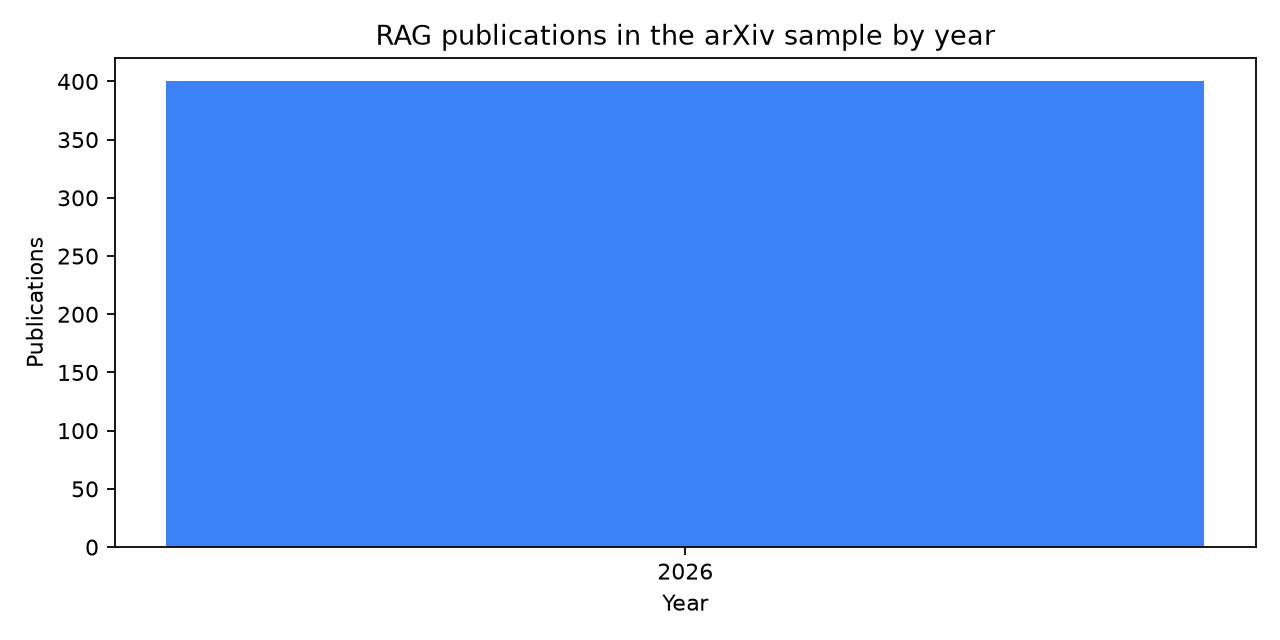

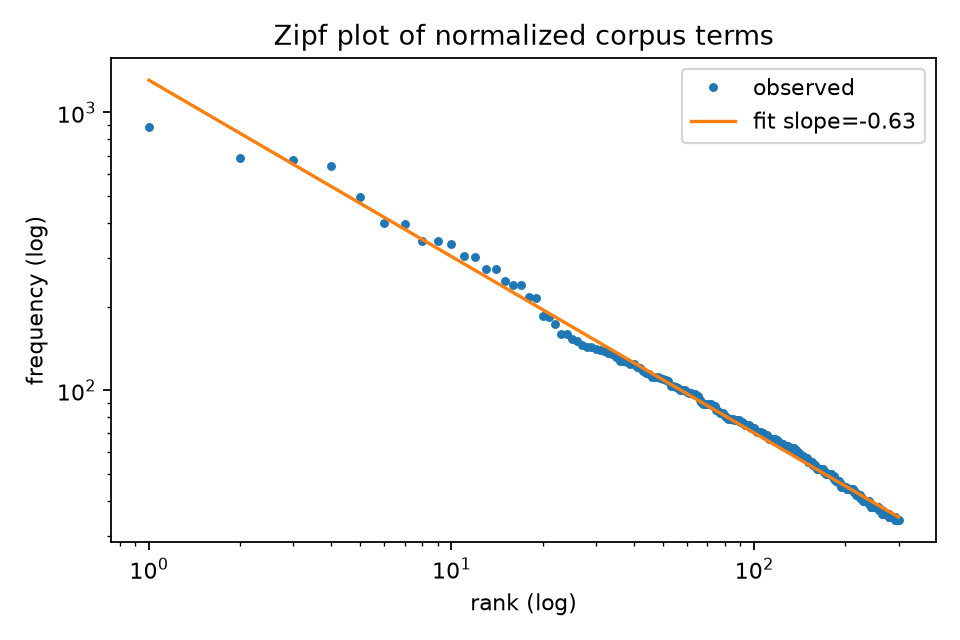

In [3]:
display(Image(filename='figures/publications_by_year.png'))
display(Image(filename='figures/zipf_law.png'))

На логарифмическом графике частота терминов убывает с ростом ранга. Полученный наклон равен примерно −0,64. Для тематически узкого корпуса после очистки текста отклонение от идеального закона Ципфа ожидаемо.

## Граф ключевых слов

Вершина графа соответствует ключевому слову или фразе. Ребро проводится между терминами, если они выбраны для одной публикации; его вес равен числу таких публикаций. Для рисунка оставлены только связи с весом не менее трёх. Сообщества выделены алгоритмом greedy modularity.

In [4]:
graph_info = summary['keyword_graph']
print(f"Вершин: {graph_info['nodes']}")
print(f"Рёбер: {graph_info['edges']}")
print(f"Сообществ: {graph_info['communities']}")
print(f"Модулярность: {graph_info['modularity']:.3f}")

communities = pd.DataFrame(summary['communities'])
communities

Вершин: 170
Рёбер: 2086
Сообществ: 5
Модулярность: 0.191


,community,size,terms
0,1,54,"evidence, question, answer, automated, report,..."
1,2,41,"query, document, hybrid, latency, strategy, at..."
2,3,32,"knowledge, graph, llm, agent, framework, tool,..."
3,4,26,"reason, agentic, memory, state, integrate, pol..."
4,5,17,"context, accuracy, chunk, metric, under, token..."


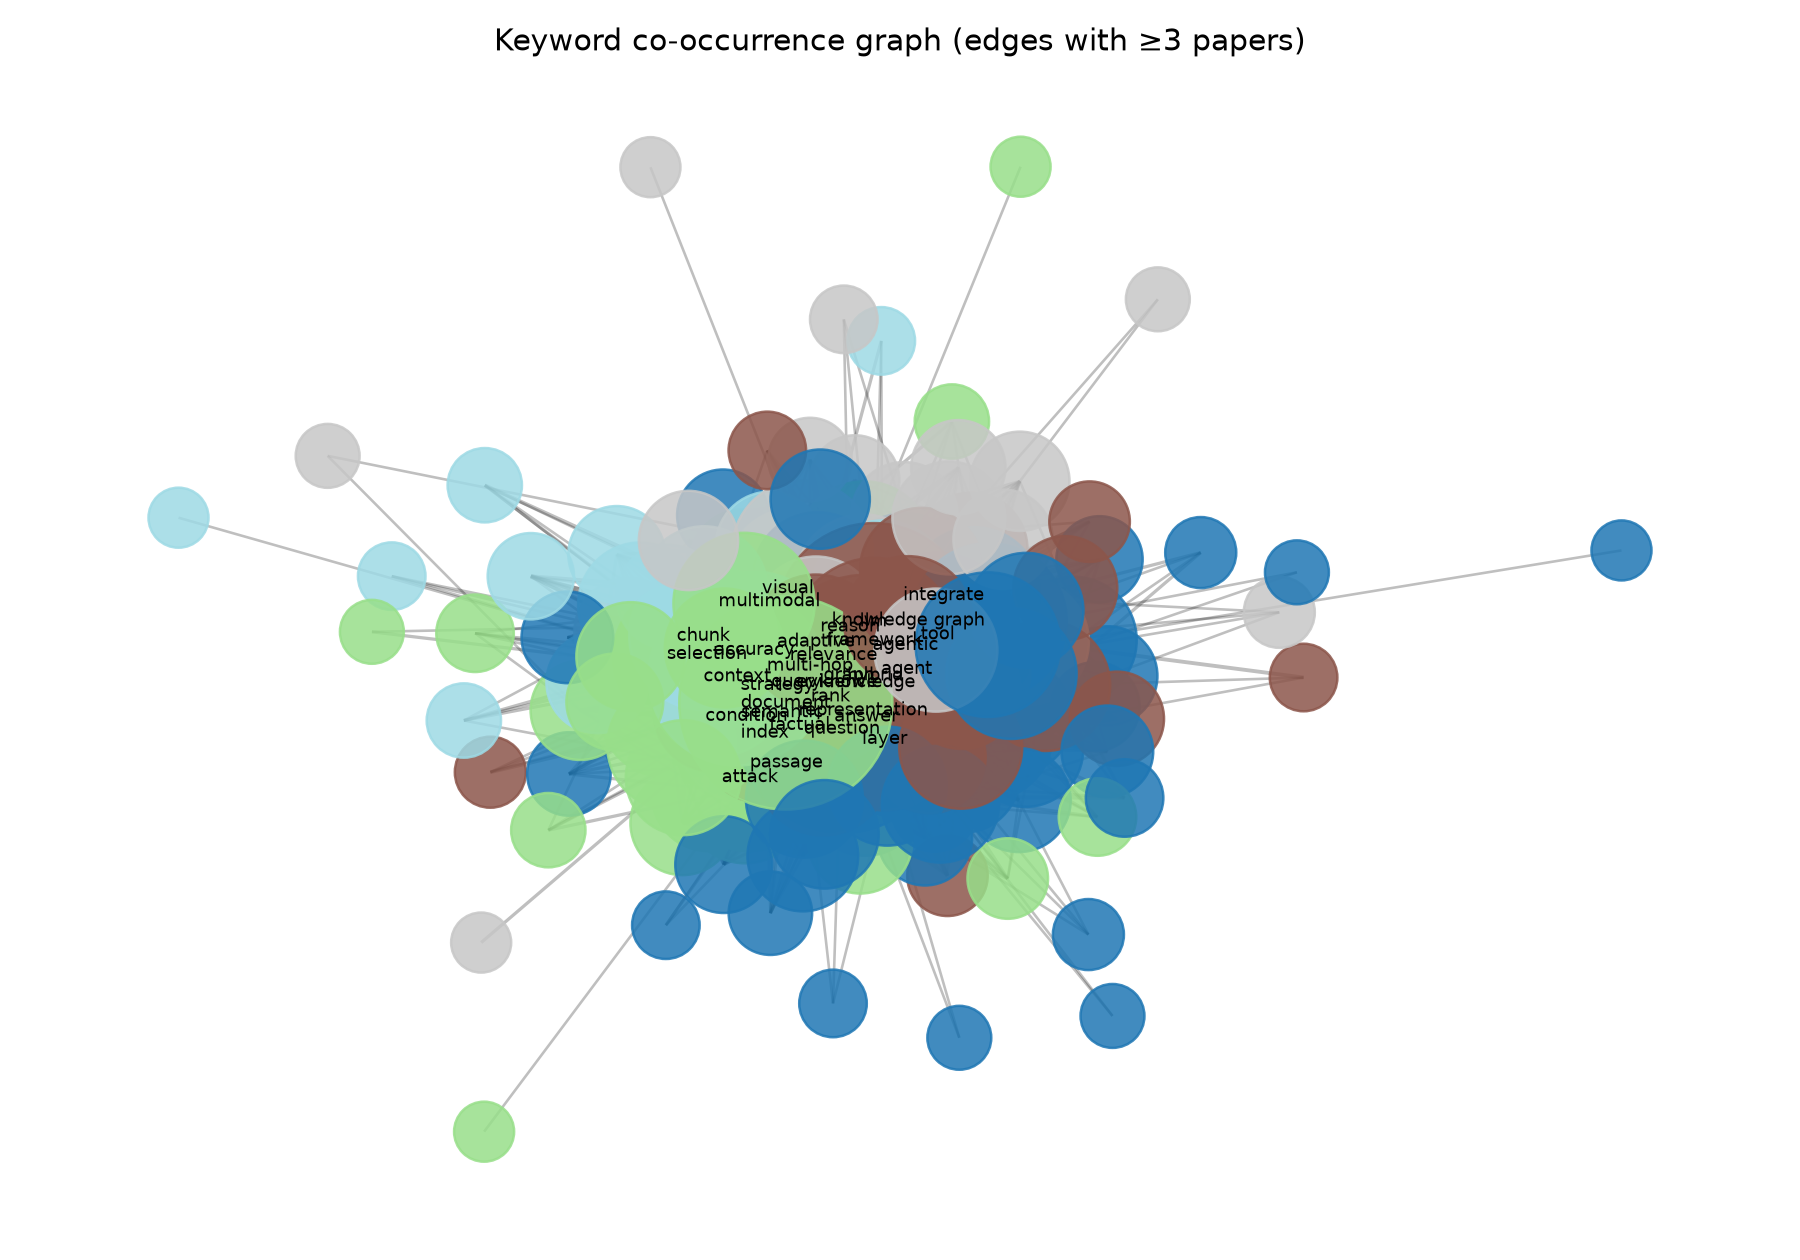

In [5]:
display(Image(filename='figures/keyword_graph.png'))

В графе выделились пять связанных тем: оценка и доказательность ответов; retrieval-пайплайн с запросами и документами; knowledge graph и LLM-агенты; агентное рассуждение с памятью; а также чанкинг и управление контекстом.

## Центральность

Для ключевых слов рассчитаны degree centrality, betweenness centrality и eigenvector centrality. Наибольшая eigenvector centrality получена у evidence, а максимальная betweenness centrality среди ведущих терминов — у question.

In [6]:
centrality = pd.DataFrame(summary['centrality_top10'])
centrality[['degree', 'betweenness', 'eigenvector']] = centrality[['degree', 'betweenness', 'eigenvector']].round(3)
centrality.head(10)

,term,degree,betweenness,eigenvector
0,evidence,0.639,0.040,0.299
1,knowledge,0.533,0.021,0.260
2,document,0.521,0.024,0.240
3,query,0.568,0.033,0.233
4,question,0.497,0.045,0.229
5,answer,0.467,0.039,0.226
6,graph,0.444,0.023,0.221
7,reason,0.408,0.033,0.186
8,context,0.349,0.034,0.144
9,agent,0.302,0.013,0.126


## Граф публикаций и поиск

В графе публикаций вершина соответствует статье. Между двумя статьями есть ребро, если у них есть общие ключевые слова; вес ребра равен числу общих терминов. Поиск возвращает соседей выбранной статьи, отсортированных по весу связи.

In [7]:
pub_graph = summary['publication_graph']
print(f"Вершин: {pub_graph['nodes']}, рёбер: {pub_graph['edges']}, плотность: {pub_graph['density']:.3f}")
print('Запрос:', summary['search_demo']['query_id'])
print(summary['search_demo']['query_title'])

results = pd.DataFrame(summary['search_demo']['results'])
results[['id', 'title', 'shared_keywords', 'keywords']]

Вершин: 400, рёбер: 39567, плотность: 0.496
Запрос: 2608.16417v1
D2-ScaleAgent: Dual-Dimensional Scaling for Long Document Understanding


,id,title,shared_keywords,keywords
0,2608.29622v1,AgenticRag-R1: Agentic Reinforcement Learning ...,5,"[adaptive, agentic, effective, memory, reason]"
1,2608.11967v1,LoongReflect: Boosting Long-Horizon Reflection...,4,"[agent, evidence, memory, reason]"
2,2609.00761v1,Agent-Enhanced Heterogeneous Graph RAG for Aca...,4,"[agent, agentic, evidence, query]"
3,2609.18182v1,WFM: Wiki Foundation Model for Complex Agentic...,4,"[agent, agentic, memory, reason]"
4,2608.15776v1,ALKEMIE Agent: an autonomous platform for comp...,3,"[adaptive, agent, agentic]"


## Вывод

В работе проанализирован корпус из 400 публикаций по RAG. В графе ключевых слов выделены пять тематических сообществ: оценка и доказательность ответов, retrieval-пайплайн, knowledge graph и агенты, агентное рассуждение, а также управление контекстом. Построенный граф публикаций позволяет находить тематически близкие статьи по общим ключевым словам.